## Assignment 2: Fine-tune a Language Model for Downstream Tasks

> CISC7021 Applied Natural Language Processing (2024/2025)

In this assignment, we will use a toy **Llama-2** language model (the same model used in Assignment 1) to conduct a sentiment analysis task using **zero-shot prompting** and **fine-tuning**, and subsequently evaluate its performance.

We will learn how to prompt the language model for sentiment classification, evaluate its task-specific performance, and perform fine-tuning using the PyTorch and Hugging Face libraries. Detailed instructions are provided in the attached notebook.

---

🚨 **How to make Full Use of Colab/Kaggle GPU Quotas?**
1. Begin by debugging your code on the CPU to ensure there are no errors, and then run it on the GPU to make full use of the available free GPU quotas.
2. In this assignment, the **inference/evaluation tasks on CPU (Task 1 & 2)** are pretty fast!
3. To clear the GPU cache, try using **torch.cuda.empty_cache()**. If you continue to run out of memory, consider restarting your environment.

🚨 Please note that training on CPU may be slow. If running on Google Colab or Kaggle, you can avoid this by going to **Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**. This should be included within the free tier of Colab.

---

We start by doing a `pip install` of all required libraries.
- 🤗 `transformers`, `datasets`, `accelerate` are Huggingface libraries.
- By default, Colab has `transformers`, `pytorch` libraries installed. If you are using a local machine, please install them via `pip` or `conda`.

In [1]:
#!pip install torch torchvision torchaudio
#!pip install transformers

In [2]:
!pip install datasets accelerate -q

### (Optional) Uploading the model/data to Google Colab or Kaggle.

⚠️ In this assignment, we will utilize online model checkpoints and datasets for improved accessibility. They will facilitate seamless transitions between different environments.

However, if you prefer to work with Google Drive or another platform, you are welcome to replace the online path with the path corresponding to your chosen environment.

For Colab users, you can mount your Google Drive files by running the following code snippet:

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

### Necessary Packages, Environment Setups

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1,2'

In [2]:
from itertools import chain

import numpy as np
import torch
from datasets import load_dataset
from tqdm.notebook import tqdm
from transformers import (
    AutoTokenizer,
    LlamaForCausalLM,
    LlamaForSequenceClassification,
    LlamaTokenizer,
    Trainer,
    TrainingArguments,
)

Please set the correct file path based on your environment.

- If you are using Colab, the path may be: `/content/drive/MyDrive/xxxxxx`
- If you are using Kaggle, the path may be: `/kaggle/input/xxxxxx`

In [3]:
# In this assignment, we will utilize online model checkpoints and datasets for improved accessibility.
# If you prefer to work with Google Drive or another platform, you are welcome to replace the online path with the path corresponding to your chosen environment.
# MODEL_FOLDER = "rzzhan/tiny-llama-stories-42m"
MODEL_FOLDER = "../assignment1/llama-42m"

Load the model checkpoint into either a GPU or CPU.

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

model_path = MODEL_FOLDER
# Load model from local files/online files
model = LlamaForCausalLM.from_pretrained(model_path).to(device)
# Load tokenizer from local files/online files
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Device type: cuda


### Task 1: Zero-shot Prompting for Sentiment Analysis

#### 💡Tutorials: How to Prompt the Language Model Using Our Prepared Function

We have developed the function `prompting_classification()` for conducting experiments on this task. To get started, you will need to prepare two hyper-parameters: the `batch size`, which should be suited to your environment, and the `prompts` for the model.

---
Minimal example:

```python
# Step 1: Load the Rotten Tomatoes dataset online
rto_data = load_dataset("cornell-movie-review-data/rotten_tomatoes")

# Step 2: Define a mapping for sentiment labels: 0 represents "bad" reviews, and 1 represents "good" reviews.
RTO_DATA_LABEL_MAPPING = {
    0: "bad",
    1: "good"
}

# Step 3: Define the prompt to be used for classification tasks.
rto_prompt = "Is this moive bad or good? This moive is "

# Call the prompting_classification function to classify movie reviews
prompting_classification(model=model,
                         tokenizer=tokenizer,
                         dataset=rto_data["validation"]["text"],
                         batch_size=32,
                         label_mapping=RTO_DATA_LABEL_MAPPING,
                         prompt=rto_prompt)

```

Important parameters:

- `dataset`: By default, we load a dataset from Huggingface hub. You can use the function defined in the previous Assignment for loading an external dataset.
- `batch_size`: The number of reviews to process in a single batch. This affects memory usage and processing speed during inference.
- `label_mapping`: A dictionary that maps numerical labels to their corresponding sentiment labels. For example, 0 maps to "bad" and 1 maps to "good".
- `prompt`: A string that serves as the prompt for the classification task. It provides context to the model about what is being asked (e.g., whether a movie is bad or good).

Returns:
- `y_pred`: e.g., `[1, 0, 1, ....]` A list containing the classification results.

---


---

By default, we have defined a function called `prompt_template` to generate prompts. However, you can also customize the prompt according to your own preferences.

```python
# Generate a prompt suffix for classification tasks based on the provided label names and text type.
prompt_template(["bad", "good"], "movie")
    -> will return "Is this moive bad or good? This moive is "
```


Important Parameters:
- `label_names` (list of str): A list of possible label names for the classification task.
- `text_type` (str): A string indicating the type of text being classified (e.g., "movie", "review").


Returns:
- `prompt_suffix`: A prompt suffix that asks whether the given text belongs to one of the specified labels.


---


⚠️ Please make sure to **run the following cell first** to define the functions.

😊 **You do not need to check the details of `predict_prob(), prompting_classification()` function!** However, if you are interested, you can refer to the following illustration figure.


Illustrations:

![illustration](https://huggingface.co/blog/assets/106_zero_shot_eval_on_the_hub/zeroshot.jpg)


In [5]:
@torch.inference_mode()
def predict_prob(model, num_labels, input_ids, label_name_ids):
    logits = model(input_ids).logits[:, -1, :]
    log_probabilities = torch.nn.functional.log_softmax(logits, dim=-1)
    class_log_prob = torch.zeros(
        (log_probabilities.shape[0], num_labels), device=log_probabilities.device
    )
    for i, label_token_ids in enumerate(label_name_ids):
        total_log_prob = torch.sum(log_probabilities[:, label_token_ids], axis=-1)
        class_log_prob[:, i] = total_log_prob
    return class_log_prob


def prompting_classification(model, tokenizer, dataset, batch_size, label_mapping, prompt):
    label_names = [label_mapping[i] for i in range(len(label_mapping))]
    num_labels = len(label_names)

    label_name_ids = [
        tokenizer.encode(label, add_special_tokens=False) for label in label_names
    ]

    y_pred = []
    for i in tqdm(range(0, len(dataset), batch_size)):
        batch_input = dataset[i : i + batch_size]
        batch_input = [i + " " + prompt for i in batch_input]
        tokenized_input = tokenizer(batch_input, return_tensors="pt", padding=True).to(
            device
        )
        class_log_prob = (
            predict_prob(
                model, num_labels, tokenized_input["input_ids"], label_name_ids
            ).detach().cpu()
        )
        preds = torch.argmax(class_log_prob, axis=1).flatten().tolist()
        y_pred += preds
    return y_pred

Dataset settings

In [9]:
# DO NOT CHANGE DATSET SOURCES! #
rto_data = load_dataset("cornell-movie-review-data/rotten_tomatoes")
sst5_data = load_dataset("SetFit/sst5")
# DO NOT CHANGE DATSET SOURCES! #

# If you wish to customize the label mapping rules, please ensure that you use synonyms.
# Avoid using terms that have opposite meanings!
RTO_DATA_LABEL_MAPPING = {0: "bad", 1: "good"}
SST5_DATA_LABEL_MAPPING = {
    0: "awful",
    1: "bad",
    2: "average",
    3: "good",
    4: "excellent",
}

Repo card metadata block was not found. Setting CardData to empty.


In [10]:
print(rto_data["train"][0])

{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}


In [11]:
print(sst5_data["train"][0])

{'text': 'a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films', 'label': 4, 'label_text': 'very positive'}


#### Task 1 Playground

---

📚 Task 1: Zero-shot Prompting for Sentiment Analysis
1. (Required) Perform zero-shot prompting for sentiment analysis on **Rotten Tomatoes** and **SST-5** dataset (dev&test).
2. (Optional) You are encouraged to change the prompts and discuss your findings.

---

In [12]:
# ⬇️ try your prompt template
def prompt_template(label_names, text_type):
    # If there are exactly two labels, join them with " or ".
    if len(label_names) == 2:
        label_name_str = " or ".join(label_names)
    else:
        # For more than two labels, join them with commas and an "or" before the last label.
        label_name_str = ", ".join(label_names[:-1]) + ", or " + label_names[-1]

    # Create the final prompt suffix.
    prompt_suffix = f"Is this {text_type} {label_name_str}? This {text_type} is "

    return prompt_suffix

In [13]:
# Skeleton Code: Zero-shot Prompting on Rotten Tomatoes dataset.

eval_batch_size = 32

label_names = [RTO_DATA_LABEL_MAPPING[i] for i in range(len(RTO_DATA_LABEL_MAPPING))]
rto_prompt = prompt_template(label_names, "movie")  # ⬅️ try your prompt template
print(f"Used Prompt: {rto_prompt}")

# Dev split
rto_val_pred = prompting_classification(
    model=model,
    tokenizer=tokenizer,
    dataset=rto_data["validation"]["text"],
    batch_size=eval_batch_size,
    label_mapping=RTO_DATA_LABEL_MAPPING,
    prompt=rto_prompt,
)

# Test split
rto_test_pred = prompting_classification(
    model=model,
    tokenizer=tokenizer,
    dataset=rto_data["test"]["text"],
    batch_size=eval_batch_size,
    label_mapping=RTO_DATA_LABEL_MAPPING,
    prompt=rto_prompt,
)

Used Prompt: Is this movie bad or good? This movie is 


  0%|          | 0/34 [00:00<?, ?it/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


  0%|          | 0/34 [00:00<?, ?it/s]

In [14]:
# Skeleton Code: Zero-shot Prompting on SST-5 dataset.

eval_batch_size = 32

label_names = [SST5_DATA_LABEL_MAPPING[i] for i in range(len(SST5_DATA_LABEL_MAPPING))]
sst5_prompt = prompt_template(label_names, "text")  # ⬅️ try your prompt template
print(f"Used Prompt: {sst5_prompt}")

sst5_val_pred = prompting_classification(
    model=model,
    tokenizer=tokenizer,
    dataset=sst5_data["validation"]["text"],
    batch_size=eval_batch_size,
    label_mapping=SST5_DATA_LABEL_MAPPING,
    prompt=sst5_prompt,
)

sst5_test_pred = prompting_classification(
    model=model,
    tokenizer=tokenizer,
    dataset=sst5_data["test"]["text"],
    batch_size=eval_batch_size,
    label_mapping=SST5_DATA_LABEL_MAPPING,
    prompt=sst5_prompt,
)

Used Prompt: Is this text awful, bad, average, good, or excellent? This text is 


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

#### Export the results for uploading. Please do not modifiy the output format!

In [15]:
def save_results(dataset, pred, output_file):
    predicted_texts = zip(dataset, pred)
    # Write the paired results to a text file
    with open(output_file, "w") as f:
        for text, prediction in predicted_texts:
            f.write(f"{prediction} ||| {text}\n")

save_results(sst5_data["validation"]["text"], sst5_val_pred, "sst5-val-prompting.txt")
save_results(sst5_data["test"]["text"], sst5_test_pred, "sst5-test-prompting.txt")
save_results(rto_data["validation"]["text"], rto_val_pred, "rto-val-prompting.txt")
save_results(rto_data["test"]["text"], rto_test_pred, "rto-test-prompting.txt")

### Task 2: Accuracy and F1 Score Evaluation

#### 💡Hints: $F_1$ score, Macro-$F_1$

---

**$F_1$ Score**

The $F_1$ score is the harmonic mean of precision and recall, providing a balance between the two. The $F_1$ score is particularly useful when the class distribution is imbalanced.


- **Precision**: $ \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} $

- **Recall**: $ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $

- **$F_1$ Score**:

  $$
  F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
  $$


---
**Macro-$F_1$ Score**

The Macro-$F_1$ score is an extension of the $F_1$ score used in multiclass classification problems. It calculates the $F_1$ score for each class independently and then takes the average, treating all classes equally regardless of their size.


  $$
  \text{Macro-}F_1 = \frac{1}{N} \sum_{i=1}^{N} F_{1,i}
  $$

  where $N$ is the number of classes and $F_{1,i}$ is the $F_1$ score for class $i$.

The Macro-$F_1$ score is useful when you want to ensure that all classes are treated equally, even if they vary in size.

---

#### Task 2 Playground

---

📚 Task 2: Accuracy and F1 score evaluation.
1. (Required) Complete the remaining code in the `calculate_f1_score` function.
2. (Required) Report the classification performance for Task 1, including the development and test performance for the Rotten Tomatoes and SST-5 datasets.

---

In [6]:
def calculate_accuracy(y_true, y_pred):
    correct_predictions = sum(1 for true, pred in zip(y_true, y_pred) if true == pred)
    accuracy = correct_predictions / len(y_true)
    return accuracy


def calculate_f1_score(y_true, y_pred, average="binary"):
    def calculate_f1(tp, fp, fn):
        if tp == 0 or tp + fp == 0 or tp + fn == 0:
            return 0.0, 0.0, 0.0  # Return precision, recall, and f1 as 0.0 when division is not possible
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        f1 = 2 * (precision * recall) / (precision + recall)
        return precision, recall, f1

    if average == "binary":
        tp = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 1)
        fp = sum(1 for true, pred in zip(y_true, y_pred) if true == 0 and pred == 1)
        fn = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 0)
        precision, recall, f1 = calculate_f1(tp, fp, fn)
        print(f"Precision: {precision}, Recall: {recall}")
        return f1

    elif average == "macro":
        classes = set(y_true)
        f1_scores = []
        precisions = []
        recalls = []
        for cls in classes:
            tp = sum(1 for true, pred in zip(y_true, y_pred) if true == cls and pred == cls)
            fp = sum(1 for true, pred in zip(y_true, y_pred) if true != cls and pred == cls)
            fn = sum(1 for true, pred in zip(y_true, y_pred) if true == cls and pred != cls)
            precision, recall, f1 = calculate_f1(tp, fp, fn)
            precisions.append(precision)
            recalls.append(recall)
            f1_scores.append(f1)
            print(f"Class {cls} - Precision: {precision}, Recall: {recall}")
        return sum(f1_scores) / len(f1_scores)


#### Export the results for uploading. Please do not modifiy the output format!

In [17]:
results = []

# RTO Data Validation
print("RTO validation")
rto_val_accuracy = calculate_accuracy(
    y_true=rto_data["validation"]["label"], y_pred=rto_val_pred
)
rto_val_f1 = calculate_f1_score(
    y_true=rto_data["validation"]["label"], y_pred=rto_val_pred
)
results.append(f"RTO Validation - Accuracy: {rto_val_accuracy}, F1 Score: {rto_val_f1}")

# RTO Data Test
print("RTO test")
rto_test_accuracy = calculate_accuracy(
    y_true=rto_data["test"]["label"], y_pred=rto_test_pred
)
rto_test_f1 = calculate_f1_score(y_true=rto_data["test"]["label"], y_pred=rto_test_pred)
results.append(f"RTO Test - Accuracy: {rto_test_accuracy}, F1 Score: {rto_test_f1}")

# SST5 Data Validation
print("SST5 validation")
sst5_val_accuracy = calculate_accuracy(
    y_true=sst5_data["validation"]["label"], y_pred=sst5_val_pred
)
sst5_val_f1 = calculate_f1_score(
    y_true=sst5_data["validation"]["label"], y_pred=sst5_val_pred, average="macro"
)
results.append(
    f"SST5 Validation - Accuracy: {sst5_val_accuracy}, F1 Score: {sst5_val_f1}"
)

# SST5 Data Test
print("SST5 test")
sst5_test_accuracy = calculate_accuracy(
    y_true=sst5_data["test"]["label"], y_pred=sst5_test_pred
)
sst5_test_f1 = calculate_f1_score(
    y_true=sst5_data["test"]["label"], y_pred=sst5_test_pred, average="macro"
)
results.append(f"SST5 Test - Accuracy: {sst5_test_accuracy}, F1 Score: {sst5_test_f1}")

# Print results
for result in results:
    print(result)

# Write results to a text file
with open("task1-scores.txt", "w") as f:
    for result in results:
        f.write(result + "\n")

RTO validation
Precision: 0.508641975308642, Recall: 0.7729831144465291
RTO test
Precision: 0.49938195302843014, Recall: 0.7579737335834896
SST5 validation
Class 0 - Precision: 0.14337568058076225, Recall: 0.5683453237410072
Class 1 - Precision: 0.16666666666666666, Recall: 0.0034602076124567475
Class 2 - Precision: 0.22264875239923224, Recall: 0.5065502183406113
Class 3 - Precision: 0.0, Recall: 0.0
Class 4 - Precision: 0.16666666666666666, Recall: 0.01818181818181818
SST5 test
Class 0 - Precision: 0.14314115308151093, Recall: 0.5161290322580645
Class 1 - Precision: 0.5, Recall: 0.00631911532385466
Class 2 - Precision: 0.17688266199649738, Recall: 0.519280205655527
Class 3 - Precision: 0.1111111111111111, Recall: 0.00196078431372549
Class 4 - Precision: 0.2222222222222222, Recall: 0.02506265664160401
RTO Validation - Accuracy: 0.5131332082551595, F1 Score: 0.6135517498138496
RTO Test - Accuracy: 0.49906191369606, F1 Score: 0.6020864381520119
SST5 Validation - Accuracy: 0.1807447774750

### Task 3: Fine-tuning base LM for Sentiment Analysis

The SST-5 dataset presents a more challenging task, given its five-label classification requirement. But our base model still struggles even with a simpler two-label classification task, underperforming compared to many models at this scale.

To enhance classification performance, particularly for the Rotten Tomatoes dataset, we need to fine-tune this model for the classification task. The base model possesses fundamental language knowledge, so we will simply build a linear classifier on top of it, similar to the approach used with BERT, as illustrated below.

![bert](https://jalammar.github.io/images/BERT-classification-spam.png)


Both the SST-5 and Rotten Tomatoes datasets contain approximately 8,000 training samples. We have already implemented data preprocessing and the training pipeline, so you are not required to optimize these components. Instead, focus on designing a more powerful classifier architecture and tuning the training hyperparameters while observing the changes in model performance.

---

⚠️ Please **make sure to run the following cell first to pre-process data and define functions**.

😄 You do not need to check the details of whole pipeline construction! **Please pay attention to the architecture of `classifier_head` and the hyper-parameters of `trainer`.**

#### 💡Tutorials: TrainingArguments().

**Important Training Hyper-parameters**
- learning_rate: The initial learning rate for optimizer.
- num_train_epochs: Total number of training epochs to perform (if not an integer, will perform the decimal part percents of the last epoch before stopping training).
- *_strategy: The evaluation/saving strategy to adopt during training. Possible values are:
    - `"no"`: No evaluation/saving is done during training.
    - `"steps"`: Evaluation/saving is done (and logged) every `eval_steps`.
    - `"epoch"`: Evaluation/saving is done at the end of each epoch.
- per_device_train_batch_size: The batch size per GPU/XPU/TPU/MPS/NPU core/CPU for training.
- per_device_eval_batch_size: The batch size per GPU/XPU/TPU/MPS/NPU core/CPU for evaluation.
- save_total_limit: If a value is passed, will limit the total amount of checkpoints.


---

If you do not understand `AdamW` optimizer and learning scheduler, you may use default settings.

**Optimizer Hyper-parameters**
- weight_decay: The weight decay to apply (if not zero) to all layers except all bias and LayerNorm weights in [`AdamW`] optimizer.
- adam_beta1: The beta1 hyperparameter for the [`AdamW`] optimizer.
- adam_beta2: The beta2 hyperparameter for the [`AdamW`] optimizer.

**Learning schedule**
- lr_scheduler: The scheduler type to use.
- warmup_ratio: Ratio of total training steps used for a linear warmup from 0 to `learning_rate`.

[Explore more parameters here](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/trainer#transformers.TrainingArguments)

#### Preprocess Data
Here, we preprocess (coverted text to tokenize ids) the text for the subsequent fine-tuning phases.

In [18]:
tokenized_rto_datasets = rto_data.map(
    lambda examples: tokenizer(examples["text"], padding="max_length", max_length=1024),
    batched=True,
    num_proc=4,
    remove_columns=["text"],
)

tokenized_sst5_datasets = sst5_data.map(
    lambda examples: tokenizer(examples["text"], padding="max_length", max_length=1024),
    batched=True,
    num_proc=4,
    remove_columns=["text"],
)

A function for visualizing the model parameters.

In [19]:
def get_model_summary(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_params = total_params - trainable_params
    print(model)
    print(f"# Total params: {total_params}")
    print(f"# Trainable params: {trainable_params}")
    print(f"# Non-trainable params: {non_trainable_params}")

#### Task 3 Playground

---

📚 Task 3: Accuracy and F1 score evaluation.

1. (Required) Fine-tune the base model on the training data for both the `Rotten Tomatoes` and `SST-5` datasets.
2. (Required) Report the classification performance of the fine-tuned model, including the development and test performance for both the Rotten Tomatoes and SST-5 datasets.
3. (Optional) Experiment with designing different architectures for the `classifier_head` and tune the hyperparameters to achieve better performance.
4. (Optional) Are there other parameter-efficient fine-tuning methods you can explore?
    -  💡Hint 1: Consider tuning only the classification layer to potentially achieve a 3x speedup.
    -  💡Hint 2: `param.requires_grad = False`.

---


##### 3.1 Tuning for Rotten Tomatoes (2 labels)

Skeleton Code: Fine-tuning on Rotten Tomatoes dataset.

In [20]:
model_path = MODEL_FOLDER
NUM_LABELS = 2 # ⬅️ number of classes (Rotten Tomatoes)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

# Load model from local files/online files
model = LlamaForSequenceClassification.from_pretrained(model_path, num_labels=NUM_LABELS).to(device)
# Load tokenizer from local files/online files
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at ../assignment1/llama-42m and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device type: cuda


In [21]:
# Simple network example for beginner: https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html
# ⬇️ Try to design a different classifier layer
classifier_head = torch.nn.Sequential(
    torch.nn.Linear(model.config.hidden_size, NUM_LABELS, bias=False)
)
model.score = classifier_head

In [22]:
get_model_summary(model)

LlamaForSequenceClassification(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 512)
    (layers): ModuleList(
      (0-7): 8 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear(in_features=512, out_features=512, bias=False)
          (k_proj): Linear(in_features=512, out_features=512, bias=False)
          (v_proj): Linear(in_features=512, out_features=512, bias=False)
          (o_proj): Linear(in_features=512, out_features=512, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=512, out_features=1376, bias=False)
          (up_proj): Linear(in_features=512, out_features=1376, bias=False)
          (down_proj): Linear(in_features=1376, out_features=512, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((512,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((512,), eps=1e-05)
      )
    )
    (norm): 

In [23]:
def compute_acc_on_train(eval_pred):
    preds = eval_pred.predictions[0] if isinstance(eval_pred.predictions, tuple) else eval_pred.predictions
    preds = np.argmax(preds, axis=1)
    result = calculate_accuracy(y_true=eval_pred.label_ids, y_pred=preds)
    return {"accuracy": result}

In [25]:
# 🚨 Release gpu cache before training the model

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(device)
    torch.cuda.empty_cache()
else:
    device = torch.device("cpu")

# =========Pre-training hyperparameters, please feel free to tune them~=========
# =Important=
output_model_path = "llama-42m-rto-full-tune" # ⬅️ Set this hyperparameter
lr = 1e-4# ⬅️ Set this hyperparameter
epochs = 8# ⬅️ Set this hyperparameter
save_steps = 50# ⬅️ Set this hyperparameter
strategy = "steps"
train_bsz = 32 # ⬅️ reduce batch size if you encountered out-of-memory errors.
eval_bsz = 32

# If you do not understand AdamW optimizer and learning scheduler, you may use default settings.
# =Optimizer=
optimizer = "adamw_torch"
weight_decay = 0.01
adam_beta1 = 0.9
adam_beta2 = 0.98
# =Learning scheduler=
lr_scheduler = "linear"
warmup_ratio = 0.01
# =========End of pre-training hyperparameters=========


training_args = TrainingArguments(
    output_model_path,
    evaluation_strategy = strategy,
    eval_steps=save_steps,
    save_strategy = strategy,
    save_steps=save_steps,
    logging_strategy="steps",
    logging_steps = 10,
    learning_rate=lr,
    weight_decay=weight_decay,
    per_device_train_batch_size=train_bsz,
    per_device_eval_batch_size=eval_bsz,
    save_total_limit=1,
    load_best_model_at_end=True,
    optim = optimizer,
    lr_scheduler_type = lr_scheduler,
    adam_beta1 = adam_beta1,
    adam_beta2 = adam_beta2,
    warmup_ratio = warmup_ratio,
    num_train_epochs = epochs,
    report_to=None
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=tokenized_rto_datasets["train"],
    eval_dataset=tokenized_rto_datasets["validation"],
    compute_metrics=compute_acc_on_train
)

trainer.train()
trainer.save_model()  # Saves the tokenizer too for easy inference

cuda


/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:34: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 0 which
    has less than 75% of the memory or cores of GPU 2. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(imbalance_warn.format(device_ids[min_pos], device_ids[max_pos]))
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda

Step,Training Loss,Validation Loss,Accuracy
50,0.557500,0.636607,0.681989
100,0.358600,0.537875,0.770169
150,0.317800,0.502034,0.793621
200,0.113800,0.601108,0.787992
250,0.146500,0.681634,0.791745
300,0.037200,2.642773,0.780488
350,0.035500,1.055169,0.789869
400,0.005400,2.283680,0.778612
450,0.000500,1.459537,0.796435
500,0.004800,2.285558,0.798311


/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:34: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 0 which
    has less than 75% of the memory or cores of GPU 2. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    env

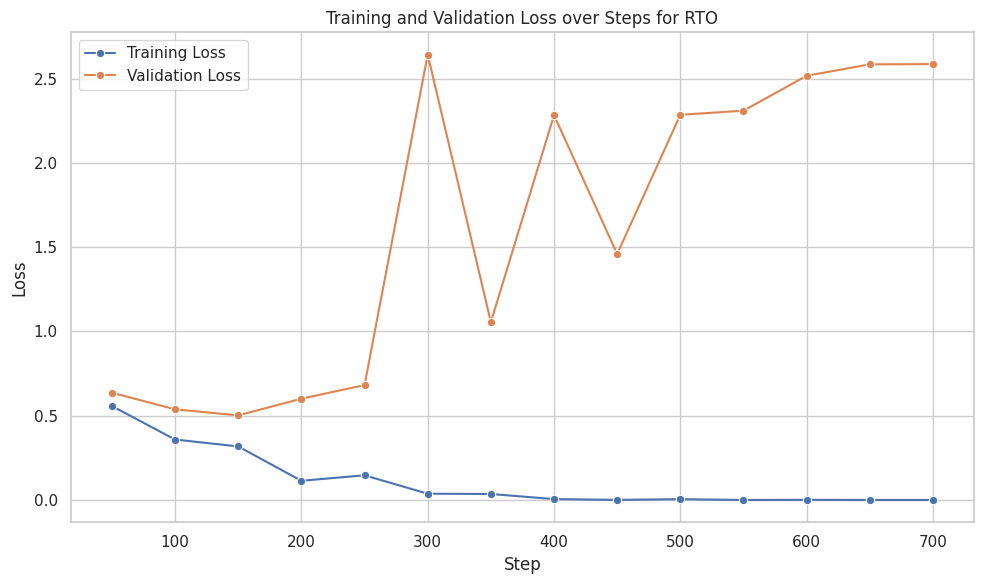

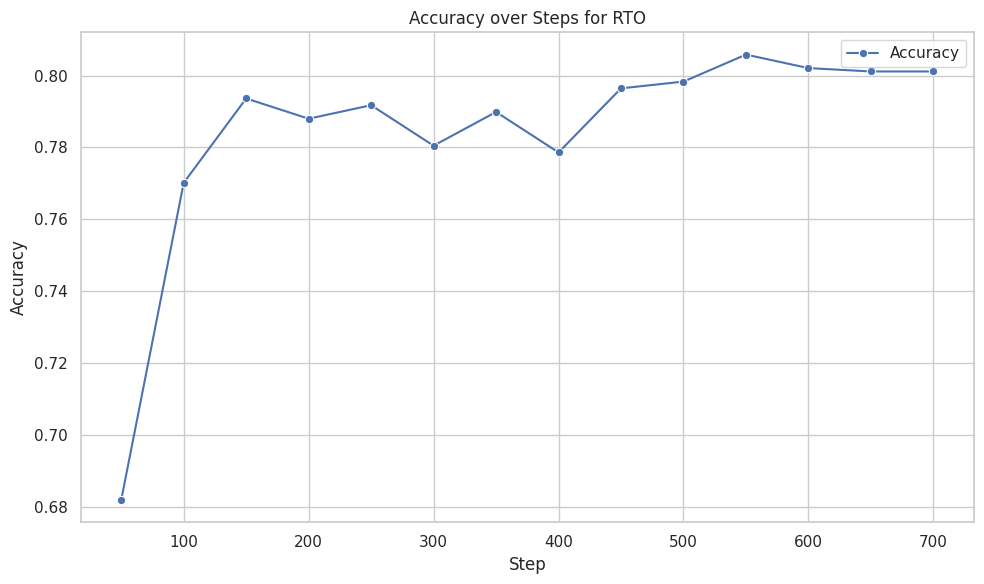

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create the dataset with updated data
data = {
    'Step': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700],
    'Training Loss': [0.557500, 0.358600, 0.317800, 0.113800, 0.146500, 0.037200, 0.035500, 0.005400, 0.000500, 0.004800, 0.000000, 0.000800, 0.000000, 0.000000],
    'Validation Loss': [0.636607, 0.537875, 0.502034, 0.601108, 0.681634, 2.642773, 1.055169, 2.283680, 1.459537, 2.285558, 2.309939, 2.517294, 2.584842, 2.586421],
    'Accuracy': [0.681989, 0.770169, 0.793621, 0.787992, 0.791745, 0.780488, 0.789869, 0.778612, 0.796435, 0.798311, 0.805816, 0.802064, 0.801126, 0.801126]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Set the plot style
sns.set(style="whitegrid")

# Plot both Training Loss and Validation Loss
plt.figure(figsize=(10, 6))
sns.lineplot(x='Step', y='Training Loss', data=df, label='Training Loss', marker='o')
sns.lineplot(x='Step', y='Validation Loss', data=df, label='Validation Loss', marker='o')

# Customize the plot
plt.title('Training and Validation Loss over Steps for RTO')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

# Save the plot as PNG
plt.savefig('training_validation_loss_RTO.png')

# Show the plot
plt.show()

# Plot the Accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(x='Step', y='Accuracy', data=df, label='Accuracy', marker='o')

# Customize the plot
plt.title('Accuracy over Steps for RTO')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

# Save the accuracy plot as PNG
plt.savefig('accuracy_over_steps_RTO.png')

# Show the plot
plt.show()


##### 3.1 Tuning for SST-5 (5 labels)
Skeleton Code: Fine-tuning on SST-5 dataset.

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

# 🚨 Release gpu cache before training the model
if device == "cuda":
    torch.cuda.empty_cache()

model_path = MODEL_FOLDER
NUM_LABELS = 5 # ⬅️ number of classes (SST-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

# Load model from local files/online files
model = LlamaForSequenceClassification.from_pretrained(model_path, num_labels=NUM_LABELS).to(device)
# Load tokenizer from local files/online files
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

# ⬇️ Try to design a different classifier layer
classifier_head = torch.nn.Sequential(
    torch.nn.Linear(model.config.hidden_size, NUM_LABELS, bias=False)
)
model.score = classifier_head

# =========Pre-training hyperparameters, please feel free to tune them~=========
# =Important=
output_model_path = "llama-42m-sst5-full-tune"# ⬅️ Set this hyperparameter
lr = 1e-4 # ⬅️ Set this hyperparameter
epochs = 8 # ⬅️ Set this hyperparameter
save_steps = 50 # ⬅️ Set this hyperparameter
strategy = "steps"
train_bsz = 32  # ⬅️ reduce batch size if you encountered out-of-memory errors.
eval_bsz = 32

# If you do not understand AdamW optimizer and learning scheduler, you may use default settings.
# =Optimizer=
optimizer = "adamw_torch"
weight_decay = 0.01
adam_beta1 = 0.9
adam_beta2 = 0.98
# =Learning scheduler=
lr_scheduler = "linear"
warmup_ratio = 0.01
# =========End of pre-training hyperparameters=========

training_args = TrainingArguments(
    output_model_path,
    evaluation_strategy = strategy,
    eval_steps=save_steps,
    save_strategy = strategy,
    save_steps=save_steps,
    logging_strategy="steps",
    logging_steps = 10,
    learning_rate=lr,
    weight_decay=weight_decay,
    per_device_train_batch_size=train_bsz,
    per_device_eval_batch_size=eval_bsz,
    save_total_limit=1,
    load_best_model_at_end=True,
    optim = optimizer,
    lr_scheduler_type = lr_scheduler,
    adam_beta1 = adam_beta1,
    adam_beta2 = adam_beta2,
    warmup_ratio = warmup_ratio,
    num_train_epochs = epochs,
    report_to=None
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=tokenized_sst5_datasets["train"],
    eval_dataset=tokenized_sst5_datasets["validation"],
    compute_metrics=compute_acc_on_train
)

trainer.train()
trainer.save_model()  # Saves the tokenizer too for easy inference

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at ../assignment1/llama-42m and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device type: cuda
Device type: cuda


/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:34: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 0 which
    has less than 75% of the memory or cores of GPU 2. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(imbalance_warn.format(device_ids[min_pos], device_ids[max_pos]))
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda

Step,Training Loss,Validation Loss,Accuracy
50,1.444500,1.364362,0.407811
100,1.041800,1.337743,0.435059
150,1.021200,1.365479,0.432334
200,0.464500,2.261516,0.415985
250,0.402300,2.062819,0.418710
300,0.089800,3.263760,0.377838
350,0.076700,3.008219,0.414169
400,0.012700,4.241930,0.418710
450,0.028200,4.253728,0.403270
500,0.019200,4.621025,0.403270


/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
/home/jpzhao/miniconda3/envs/CISC7021/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:34: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 0 which
    has less than 75% of the memory or cores of GPU 2. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    env

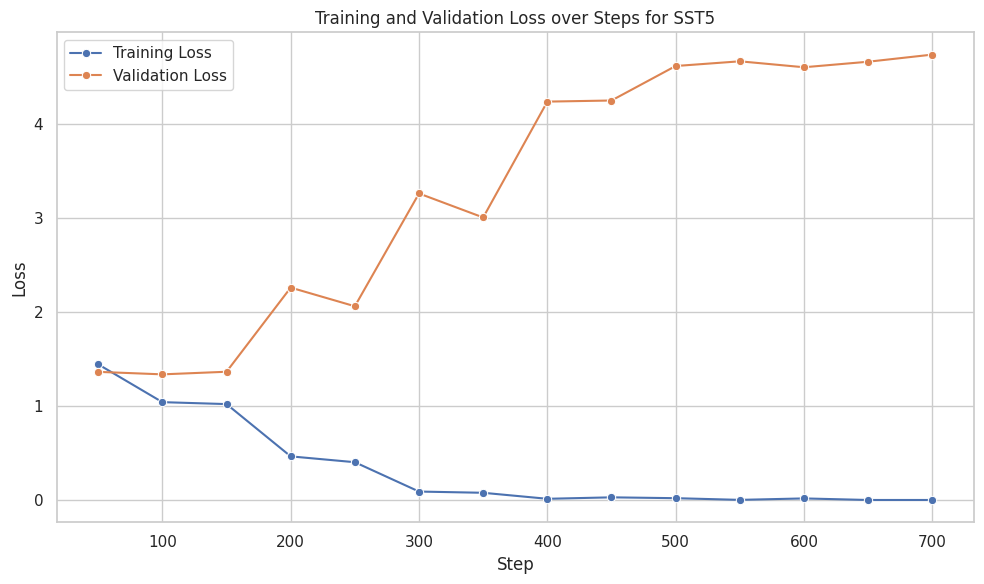

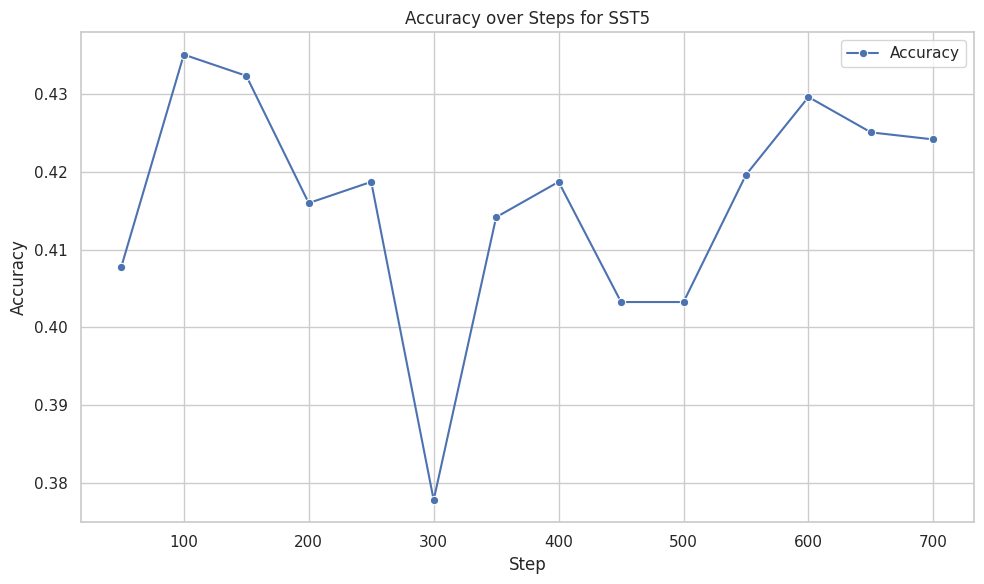

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create the dataset with updated data
data = {
    'Step': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700],
    'Training Loss': [1.444500, 1.041800, 1.021200, 0.464500, 0.402300, 0.089800, 0.076700, 0.012700, 0.028200, 0.019200, 0.001300, 0.016700, 0.000100, 0.000100],
    'Validation Loss': [1.364362, 1.337743, 1.365479, 2.261516, 2.062819, 3.263760, 3.008219, 4.241930, 4.253728, 4.621025, 4.671093, 4.607768, 4.666647, 4.742508],
    'Accuracy': [0.407811, 0.435059, 0.432334, 0.415985, 0.418710, 0.377838, 0.414169, 0.418710, 0.403270, 0.403270, 0.419619, 0.429609, 0.425068, 0.424160]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Set the plot style
sns.set(style="whitegrid")

# Plot both Training Loss and Validation Loss
plt.figure(figsize=(10, 6))
sns.lineplot(x='Step', y='Training Loss', data=df, label='Training Loss', marker='o')
sns.lineplot(x='Step', y='Validation Loss', data=df, label='Validation Loss', marker='o')

# Customize the plot
plt.title('Training and Validation Loss over Steps for SST5')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

# Save the plot as PNG
plt.savefig('training_validation_loss_SST5.png')

# Show the plot
plt.show()

# Plot the Accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(x='Step', y='Accuracy', data=df, label='Accuracy', marker='o')

# Customize the plot
plt.title('Accuracy over Steps for SST5')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

# Save the accuracy plot as PNG
plt.savefig('accuracy_over_steps_SST5.png')

# Show the plot
plt.show()


##### 3.2 Evaluate fine-tuned models
You can restart your environment here to avoid out-of-memory issue. Please remember to load missing functions like `calculate_accuracy`, `calculate_f1_score`.

⚠️ You can skip reading these preparation functions. Please **make sure to run the following cell first to define functions**.

In [7]:
import torch
import os
from safetensors import safe_open
from datasets import load_dataset
from transformers import LlamaForSequenceClassification, AutoTokenizer, AutoConfig
from tqdm.notebook import tqdm

def load_saved_checkpoint(model_path, num_labels, classifier_head, device):
    model = LlamaForSequenceClassification.from_pretrained(model_path, num_labels=num_labels)
    tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        model.config.pad_token_id = tokenizer.eos_token_id

    model.score = classifier_head

    tensors = {}
    with safe_open(os.path.join(model_path, "model.safetensors"), framework="pt", device="cpu") as f:
        for key in f.keys():
            tensors[key] = f.get_tensor(key)

    model.load_state_dict(tensors, strict=True)
    model = model.to(device)
    return model, tokenizer

def finetuned_classification(model, tokenizer, dataset, batch_size):
    y_pred = []
    for i in tqdm(range(0, len(dataset), batch_size)):
        batch_input = dataset[i:i+batch_size]
        batch_input = [i for i in batch_input]
        tokenized_input = tokenizer(batch_input, return_tensors="pt", padding=True).to(device)
        class_log_prob = model(tokenized_input["input_ids"]).logits.detach().cpu()
        preds = torch.argmax(class_log_prob, axis=1).flatten().tolist()
        y_pred += preds
    return y_pred

rto_data = load_dataset("cornell-movie-review-data/rotten_tomatoes")
sst5_data = load_dataset("SetFit/sst5")

Repo card metadata block was not found. Setting CardData to empty.


3.2 Evaluate fine-tuned "Rotten Tomatoes" model

In [10]:
eval_batch_size = 32

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

# 🚨 Release gpu cache before training the model
if device == "cuda":
    torch.cuda.empty_cache()


model_path = "llama-42m-rto-full-tune" # ⬅️ your saved checkpoint path
config = AutoConfig.from_pretrained(model_path)
NUM_LABELS = config.num_labels

# ⬇️ copy your classifier architecture here
classifier_head = torch.nn.Sequential(
    torch.nn.Linear(config.hidden_size, NUM_LABELS, bias=False)
)

model, tokenizer = load_saved_checkpoint(model_path, num_labels=NUM_LABELS, classifier_head=classifier_head, device=device)
tuned_rto_val_pred = finetuned_classification(model=model, tokenizer=tokenizer, dataset=rto_data["validation"]["text"], batch_size=eval_batch_size)
tuned_rto_test_pred = finetuned_classification(model=model, tokenizer=tokenizer, dataset=rto_data["test"]["text"], batch_size=eval_batch_size)

Some weights of the model checkpoint at llama-42m-rto-full-tune were not used when initializing LlamaForSequenceClassification: ['score.0.weight']
- This IS expected if you are initializing LlamaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing LlamaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at llama-42m-rto-full-tune and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device type: cuda


  0%|          | 0/34 [00:00<?, ?it/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


  0%|          | 0/34 [00:00<?, ?it/s]

3.2 Evaluate fine-tuned "SST-5" model

In [12]:
eval_batch_size = 32

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

# 🚨 Release gpu cache before training the model
if device == "cuda":
    torch.cuda.empty_cache()


model_path = "llama-42m-sst5-full-tune" # ⬅️ your saved checkpoint path
config = AutoConfig.from_pretrained(model_path)
NUM_LABELS = config.num_labels

# ⬇️ copy your classifier architecture here
classifier_head = torch.nn.Sequential(
    torch.nn.Linear(config.hidden_size, NUM_LABELS, bias=False)
)

model, tokenizer = load_saved_checkpoint(model_path, num_labels=NUM_LABELS, classifier_head=classifier_head, device=device)

tuned_sst5_val_pred = finetuned_classification(model=model, tokenizer=tokenizer, dataset=sst5_data["validation"]["text"], batch_size=eval_batch_size)
tuned_sst5_test_pred = finetuned_classification(model=model, tokenizer=tokenizer, dataset=sst5_data["test"]["text"], batch_size=eval_batch_size)

Some weights of the model checkpoint at llama-42m-sst5-full-tune were not used when initializing LlamaForSequenceClassification: ['score.0.weight']
- This IS expected if you are initializing LlamaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing LlamaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at llama-42m-sst5-full-tune and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device type: cuda


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

#### Export the results for uploading. Please do not modifiy the output format!

In [15]:
results = []

# RTO Data Validation
print("RTO Data Validation")
rto_val_accuracy = calculate_accuracy(y_true=rto_data["validation"]["label"], y_pred=tuned_rto_val_pred)
rto_val_f1 = calculate_f1_score(y_true=rto_data["validation"]["label"], y_pred=tuned_rto_val_pred)
results.append(f"RTO Validation - Accuracy: {rto_val_accuracy}, F1 Score: {rto_val_f1}")

# RTO Data Test
print("RTO Data Test")
rto_test_accuracy = calculate_accuracy(y_true=rto_data["test"]["label"], y_pred=tuned_rto_test_pred)
rto_test_f1 = calculate_f1_score(y_true=rto_data["test"]["label"], y_pred=tuned_rto_test_pred)
results.append(f"RTO Test - Accuracy: {rto_test_accuracy}, F1 Score: {rto_test_f1}")

# SST5 Data Validation
print("SST5 Data Validation")
sst5_val_accuracy = calculate_accuracy(y_true=sst5_data["validation"]["label"], y_pred=tuned_sst5_val_pred)
sst5_val_f1 = calculate_f1_score(y_true=sst5_data["validation"]["label"], y_pred=tuned_sst5_val_pred, average="macro")
results.append(f"SST5 Validation - Accuracy: {sst5_val_accuracy}, F1 Score: {sst5_val_f1}")

# SST5 Data Test
print("SST5 Data Test")
sst5_test_accuracy = calculate_accuracy(y_true=sst5_data["test"]["label"], y_pred=tuned_sst5_test_pred)
sst5_test_f1 = calculate_f1_score(y_true=sst5_data["test"]["label"], y_pred=tuned_sst5_test_pred, average="macro")
results.append(f"SST5 Test - Accuracy: {sst5_test_accuracy}, F1 Score: {sst5_test_f1}")

# Print results
for result in results:
    print(result)

# Write results to a text file
with open('task3-scores.txt', 'w') as f:
    for result in results:
        f.write(result + '\n')

RTO Data Validation
Precision: 0.7992351816443595, Recall: 0.7842401500938087
RTO Data Test
Precision: 0.8076923076923077, Recall: 0.7879924953095685
SST5 Data Validation
Class 0 - Precision: 0.6206896551724138, Recall: 0.12949640287769784
Class 1 - Precision: 0.45057471264367815, Recall: 0.6782006920415224
Class 2 - Precision: 0.31835205992509363, Recall: 0.37117903930131
Class 3 - Precision: 0.49710982658959535, Recall: 0.30824372759856633
Class 4 - Precision: 0.47715736040609136, Recall: 0.5696969696969697
SST5 Data Test
Class 0 - Precision: 0.7368421052631579, Recall: 0.1003584229390681
Class 1 - Precision: 0.4888366627497062, Recall: 0.6571879936808847
Class 2 - Precision: 0.27807486631016043, Recall: 0.40102827763496146
Class 3 - Precision: 0.44559585492227977, Recall: 0.33725490196078434
Class 4 - Precision: 0.5641711229946524, Recall: 0.5288220551378446
RTO Validation - Accuracy: 0.7936210131332082, F1 Score: 0.7916666666666667
RTO Test - Accuracy: 0.800187617260788, F1 Score: 

In [14]:
def save_results(dataset, pred, output_file):
    predicted_texts = zip(dataset, pred)
    # Write the paired results to a text file
    with open(output_file, "w") as f:
        for text, prediction in predicted_texts:
            f.write(f"{prediction} ||| {text}\n")

save_results(sst5_data["validation"]["text"], tuned_sst5_val_pred, "sst5-val-finetuned.txt")
save_results(sst5_data["test"]["text"], tuned_sst5_test_pred, "sst5-test-finetuned.txt")
save_results(rto_data["validation"]["text"], tuned_rto_val_pred, "rto-val-finetuned.txt")
save_results(rto_data["test"]["text"], tuned_rto_test_pred, "rto-test-finetuned.txt")

In [44]:
ls *.txt

rto-test-finetuned.txt  rto-val-prompting.txt    sst5-val-finetuned.txt  task3-scores.txt
rto-test-prompting.txt  sst5-test-finetuned.txt  sst5-val-prompting.txt
rto-val-finetuned.txt   sst5-test-prompting.txt  task1-scores.txt


In [18]:
from sklearn.metrics import f1_score

# Precision and recall values for each class
precision_validation = [0.6206896551724138, 0.45057471264367815, 0.31835205992509363, 
                        0.49710982658959535, 0.47715736040609136]
recall_validation = [0.12949640287769784, 0.6782006920415224, 0.37117903930131, 
                     0.30824372759856633, 0.5696969696969697]

precision_test = [0.7368421052631579, 0.4888366627497062, 0.27807486631016043, 
                  0.44559585492227977, 0.5641711229946524]
recall_test = [0.1003584229390681, 0.6571879936808847, 0.40102827763496146, 
               0.33725490196078434, 0.5288220551378446]

# Function to calculate F1 score for each class
def calculate_f1(precision, recall):
    return [2 * (p * r) / (p + r) if (p + r) > 0 else 0 for p, r in zip(precision, recall)]

# Calculate F1 scores for validation and test sets
f1_scores_validation = calculate_f1(precision_validation, recall_validation)
f1_scores_test = calculate_f1(precision_test, recall_test)

f1_scores_validation, f1_scores_test


([0.2142857142857143,
  0.5414364640883979,
  0.34274193548387094,
  0.3805309734513274,
  0.5193370165745856],
 [0.1766561514195584,
  0.5606469002695418,
  0.328421052631579,
  0.38392857142857145,
  0.5459249676584735])